Note: If SciPy isn't installed, linear interpolation falls back to NumPy. Update `water_csv` if your water-level file is in a different location. The notebook writes outputs into each clip folder and combined files in the root.

# Build 3D Beach Surface from Averaged Shorelines

This notebook discovers shoreline clips in `seabright_new_rec`, parses UTC timestamps from folder names, interpolates NOAA water levels (feet→meters), resamples each shoreline to N=400 points parameterized by `u∈[0,1]`, writes per-clip and combined CSVs, builds a triangulated 3D surface across time, exports as PLY/OBJ, and generates minimal sanity plots.

In [1]:
# 1) Set up imports, paths, and parameters
import os, re, glob, json, math
from pathlib import Path
from datetime import datetime, timezone
from typing import List, Tuple, Optional, Dict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401, needed for 3D projection

try:
    from scipy.interpolate import interp1d
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

# Root directory containing baseline and clip subfolders
root_dir = Path("c:/Users/remote/Documents/GitHub/sam2_realtime/save_predict/shoreline_jsons/csv/seabright_new_rec")
# Under root, the deepest curves are inside the 'averaged' subfolder with 12 clip directories
averaged_dir = root_dir / "averaged"
# NOAA water level CSV (GMT). Update path if needed.
water_csv = Path("c:/Users/remote/Documents/GitHub/sam2_realtime/save_predict/shoreline_jsons/csv/waterlevel/CO-OPS_9413450_wl1.csv")

# Output locations
out_combined_csv = root_dir / "all_averaged_3d.csv"
ply_path = root_dir / "beach_surface.ply"
obj_path = root_dir / "beach_surface.obj"

# Parameters
N = 400  # points per shoreline curve
FEET_TO_M = 0.3048
FILL_EXTRAPOLATE = True  # whether to extrapolate tide beyond provided range

# Visual-only scaling for the 3D preview (does not affect exported meshes)
# Use values >> 1.0 to increase vertical exaggeration; try 50, 200, 500 depending on XY span vs tide range.

ASPECT_Z_BOOST = 1.0  # extra boost for z axis aspect only (multiplies the z box aspect)

# Helper: simple logger

def log(*args):
    print("[build]", *args)

# Helper: case-insensitive column getter with fallbacks

def get_col(df: pd.DataFrame, names: List[str]) -> Optional[str]:
    cols = {c.strip().lower(): c for c in df.columns}
    for name in names:
        key = name.strip().lower()
        if key in cols:
            return cols[key]
    return None

# Read CSV robustly with pandas

def read_csv_robust(path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(path)
    except Exception:
        return pd.read_csv(path, engine="python")

log("Root:", root_dir)
if not root_dir.exists():
    raise FileNotFoundError(f"Root folder not found: {root_dir}")
if not averaged_dir.exists():
    raise FileNotFoundError(f"Averaged folder not found: {averaged_dir}")
log("Averaged path:", averaged_dir)


[build] Root: c:\Users\remote\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\csv\seabright_new_rec
[build] Averaged path: c:\Users\remote\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\csv\seabright_new_rec\averaged


In [2]:
# 2) Discover clips under 'averaged' and select shoreline CSVs (prefer '*deepest*' or '*averaged*')

def rank_csvs(file_list: List[Path]) -> List[Path]:
    def score(p: Path) -> Tuple[int, str]:
        name = p.name.lower()
        s = 0
        if "deepest" in name:
            s += 2
        if "averaged" in name or "average" in name:
            s += 1
        return (s, f"{1000-len(name):04d}")
    return sorted(file_list, key=score, reverse=True)

clip_dirs = [p for p in averaged_dir.iterdir() if p.is_dir()]
clip_dirs = sorted(clip_dirs)

selected: List[Tuple[Path, Path]] = []  # (clip_dir, shoreline_csv)
for d in clip_dirs:
    csvs = [Path(p) for p in glob.glob(str(d / "*.csv"))]
    if not csvs:
        log("No CSVs in", d)
        continue
    for p in rank_csvs(csvs):
        df = read_csv_robust(p)
        xcol = get_col(df, ["X_warped", "x_warped", "X", "x"]) or ""
        ycol = get_col(df, ["Y_warped", "y_warped", "Y", "y"]) or ""
        if xcol and ycol and df[[xcol, ycol]].dropna().shape[0] >= 2:
            selected.append((d, p))
            break
    else:
        log("No valid shoreline CSV with X/Y in", d)

log(f"Discovered {len(selected)} averaged clip folders with shoreline CSVs.")
if len(selected) == 0:
    raise RuntimeError("No shoreline CSVs found under 'averaged'. Check folder structure and names.")


[build] Discovered 12 averaged clip folders with shoreline CSVs.


In [3]:
# 3) Parse UTC timestamps from averaged clip folder names

# Patterns (ordered):
# 1) site-YYYY-MM-DD-HHMMSSZ (e.g., walton_lighthouse-2024-01-11-233423Z)
# 2) YYYY-MM-DDTHHMMZ
# 3) standalone HHMM (infer date later)

def parse_timestamp_from_name(name: str) -> Tuple[Optional[datetime], Optional[str]]:
    s = name.lower()
    # Pattern 1
    m = re.search(r"(\d{4})-(\d{2})-(\d{2})-(\d{6})z", s)
    if m:
        y, mo, d, hhmmss = m.groups()
        hh, mm, ss = int(hhmmss[:2]), int(hhmmss[2:4]), int(hhmmss[4:6])
        try:
            return datetime(int(y), int(mo), int(d), hh, mm, ss, tzinfo=timezone.utc), "p1"
        except Exception:
            pass
    # Pattern 2
    m = re.search(r"(\d{4})-(\d{2})-(\d{2})t(\d{4})z", s)
    if m:
        y, mo, d, hhmm = m.groups()
        hh, mm = int(hhmm[:2]), int(hhmm[2:4])
        try:
            return datetime(int(y), int(mo), int(d), hh, mm, 0, tzinfo=timezone.utc), "p2"
        except Exception:
            pass
    # Pattern 3
    m = re.search(r"(^|[-_])(?P<hhmm>\d{4})(?=$|[-_])", s)
    if m:
        hhmm = m.group("hhmm")
        hh, mm = int(hhmm[:2]), int(hhmm[2:4])
        return datetime(1970, 1, 1, hh, mm, 0, tzinfo=timezone.utc), "p3"
    return None, None

clips_info: List[Dict] = []
for d, csv_path in selected:
    ts, pattern = parse_timestamp_from_name(d.name)
    clips_info.append({
        "dir": d,
        "csv": csv_path,
        "ts": ts,  # may be placeholder if pattern 3
        "pattern": pattern,
    })

log("Parsed timestamps (pre-water-level alignment):", sum(1 for x in clips_info if x["ts"] is not None))


[build] Parsed timestamps (pre-water-level alignment): 12


In [4]:
# 4) Load NOAA water-level CSV (GMT), choose Verified or Predicted (ft), convert to meters

wl_df_raw = read_csv_robust(water_csv)
cols_norm = {c: c.strip().lower() for c in wl_df_raw.columns}
wl_df = wl_df_raw.rename(columns=cols_norm)

# Find datetime columns in various forms
# Common forms: 'date' + 'time (gmt)' OR 'datetime (gmt)'
if 'date' in wl_df.columns and any(k in wl_df.columns for k in ['time (gmt)', 'time', 'time gmt']):
    tcol = 'time (gmt)' if 'time (gmt)' in wl_df.columns else ('time' if 'time' in wl_df.columns else 'time gmt')
    dt = pd.to_datetime(wl_df['date'].astype(str) + ' ' + wl_df[tcol].astype(str), utc=True, errors='coerce')
elif any(k in wl_df.columns for k in ['datetime (gmt)', 'datetime', 'date time (gmt)']):
    k = 'datetime (gmt)' if 'datetime (gmt)' in wl_df.columns else ('date time (gmt)' if 'date time (gmt)' in wl_df.columns else 'datetime')
    dt = pd.to_datetime(wl_df[k].astype(str), utc=True, errors='coerce')
else:
    raise RuntimeError("Could not find datetime columns in water level CSV.")

wl_df['dt'] = dt

# Choose Verified (ft) else Predicted (ft), accept variants
cand_cols = [
    'verified (ft)', 'verified', 'verified(ft)',
    'water level (verified) (ft)', 'wl verified (ft)',
    'predicted (ft)', 'predicted', 'predicted(ft)'
]
level_col = None
for c in cand_cols:
    c_low = c.strip().lower()
    if c_low in wl_df.columns:
        level_col = c_low
        break
if level_col is None:
    # try to find any column with '(ft)' that looks numeric
    ft_like = [c for c in wl_df.columns if '(ft' in c]
    if ft_like:
        level_col = ft_like[0]
if level_col is None:
    raise RuntimeError("No Verified/Predicted feet column found in water level CSV.")

wl_df['z_ft'] = pd.to_numeric(wl_df[level_col], errors='coerce')
wl_df['z_m'] = wl_df['z_ft'] * FEET_TO_M
wl_df = wl_df.dropna(subset=['dt', 'z_m']).sort_values('dt')
wl_df = wl_df.drop_duplicates(subset=['dt'], keep='last').reset_index(drop=True)

log("Water series length:", len(wl_df), "from", wl_df['dt'].min(), "to", wl_df['dt'].max())

# Convenience arrays for interpolation
wl_times = wl_df['dt'].astype('int64') // 10**9  # seconds since epoch
wl_vals = wl_df['z_m'].values.astype(float)

if SCIPY_AVAILABLE:
    f_wl = interp1d(wl_times.values, wl_vals, kind='linear', fill_value='extrapolate' if FILL_EXTRAPOLATE else np.nan, bounds_error=False)
else:
    def f_wl(ts_sec):
        x = wl_times.values.astype(float)
        y = wl_vals
        ts = np.asarray(ts_sec, dtype=float)
        # np.interp handles ascending x only
        return np.interp(ts, x, y, left=(y[0] if FILL_EXTRAPOLATE else np.nan), right=(y[-1] if FILL_EXTRAPOLATE else np.nan))


[build] Water series length: 240 from 2024-01-11 00:00:00+00:00 to 2024-01-11 23:54:00+00:00


In [5]:
# Fill dates for HHMM-only clips and compute tide at each clip timestamp

# Determine a reasonable base date: choose the date range covering water level series
wl_min = wl_df['dt'].min()
base_date = datetime(wl_min.year, wl_min.month, wl_min.day, tzinfo=timezone.utc)

resolved = []
for info in clips_info:
    ts = info['ts']
    if ts is None:
        log("Could not parse timestamp:", info['dir'].name)
        continue
    if info['pattern'] == 'p3':
        # Replace YYYY-MM-DD with base_date
        ts = datetime(base_date.year, base_date.month, base_date.day, ts.hour, ts.minute, ts.second, tzinfo=timezone.utc)
    info['ts_resolved'] = ts
    # Interpolate tide
    ts_sec = int(ts.timestamp())
    info['tide_m'] = float(f_wl([ts_sec])[0])
    resolved.append(info)

clips_info = sorted(resolved, key=lambda x: x['ts_resolved'])
log("Resolved", len(clips_info), "clips after timestamp assignment.")

# Summary DataFrame
clips_df = pd.DataFrame([{ 'clip': i['dir'].name, 'timestamp': i['ts_resolved'], 'csv': str(i['csv']), 'tide_m': i['tide_m'] } for i in clips_info])
clips_df

[build] Resolved 12 clips after timestamp assignment.


,clip,timestamp,csv,tide_m
0,walton_lighthouse-2024-01-11-180046Z,2024-01-11 18:00:46+00:00,c:\Users\remote\Documents\GitHub\sam2_realtime...,1.986195
1,walton_lighthouse-2024-01-11-183046Z,2024-01-11 18:30:46+00:00,c:\Users\remote\Documents\GitHub\sam2_realtime...,1.889303
2,walton_lighthouse-2024-01-11-190046Z,2024-01-11 19:00:46+00:00,c:\Users\remote\Documents\GitHub\sam2_realtime...,1.740730
3,walton_lighthouse-2024-01-11-193046Z,2024-01-11 19:30:46+00:00,c:\Users\remote\Documents\GitHub\sam2_realtime...,1.570296
4,walton_lighthouse-2024-01-11-200046Z,2024-01-11 20:00:46+00:00,c:\Users\remote\Documents\GitHub\sam2_realtime...,1.341696
5,walton_lighthouse-2024-01-11-203748Z,2024-01-11 20:37:48+00:00,c:\Users\remote\Documents\GitHub\sam2_realtime...,1.035710
6,walton_lighthouse-2024-01-11-210748Z,2024-01-11 21:07:48+00:00,c:\Users\remote\Documents\GitHub\sam2_realtime...,0.774802
7,walton_lighthouse-2024-01-11-212748Z,2024-01-11 21:27:48+00:00,c:\Users\remote\Documents\GitHub\sam2_realtime...,0.579831
8,walton_lighthouse-2024-01-11-215748Z,2024-01-11 21:57:48+00:00,c:\Users\remote\Documents\GitHub\sam2_realtime...,0.322986
9,walton_lighthouse-2024-01-11-223423Z,2024-01-11 22:34:23+00:00,c:\Users\remote\Documents\GitHub\sam2_realtime...,0.023343


In [6]:
# 6) Load baseline_warped.csv and compute reference direction

baseline_csv = root_dir / 'baseline_warped.csv'
base_df = read_csv_robust(baseline_csv)
xb = get_col(base_df, ["X_warped","x_warped","X","x"]) or None
yb = get_col(base_df, ["Y_warped","y_warped","Y","y"]) or None
if xb is None or yb is None:
    log("baseline_warped.csv missing X/Y; proceeding without enforcing orientation.")
    baseline_dir = None
else:
    base_pts = base_df[[xb,yb]].dropna().to_numpy(float)
    if len(base_pts) >= 2:
        v = base_pts[-1] - base_pts[0]
        L = np.linalg.norm(v)
        if not np.isfinite(L) or L == 0:
            mu = base_pts.mean(axis=0)
            U, S, VT = np.linalg.svd(base_pts - mu, full_matrices=False)
            v = VT[0]
        else:
            v = v / L
        baseline_dir = v / (np.linalg.norm(v) + 1e-12)
        log("Baseline direction:", baseline_dir)
    else:
        baseline_dir = None
        log("baseline_warped.csv has <2 points; orientation not enforced.")


[build] Baseline direction: [ 0.95942141 -0.28197615]


In [7]:
# 7) Read, validate, and resample each shoreline to N=400 with u∈[0,1]

def resample_polyline_xy(xy: np.ndarray, N: int) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    # Remove duplicates
    diffs = np.linalg.norm(np.diff(xy, axis=0), axis=1, ord=2)
    keep = np.hstack([[True], diffs > 0])
    xy = xy[keep]
    if len(xy) < 2:
        raise ValueError("Polyline needs >=2 unique points")
    ds = np.r_[0.0, np.cumsum(np.linalg.norm(np.diff(xy, axis=0), axis=1))]
    if ds[-1] == 0:
        raise ValueError("Zero-length polyline")
    u_src = ds / ds[-1]
    u_tgt = np.linspace(0, 1, N)
    x = np.interp(u_tgt, u_src, xy[:,0])
    y = np.interp(u_tgt, u_src, xy[:,1])
    return u_tgt, x, y

per_clip_outputs: List[Dict] = []
for info in clips_info:
    df = read_csv_robust(info['csv'])
    xcol = get_col(df, ["X_warped","x_warped","X","x"]) or None
    ycol = get_col(df, ["Y_warped","y_warped","Y","y"]) or None
    if xcol is None or ycol is None:
        log("Skipping (no X/Y):", info['csv'])
        continue
    xy = df[[xcol, ycol]].dropna().astype(float).to_numpy()
    if len(xy) < 2:
        log("Skipping (too few points):", info['csv'])
        continue
    # Enforce consistent orientation by projection onto baseline (if available)
    try:
        proj = (xy - xy[0]) @ baseline_dir
        if proj[-1] < proj[0]:
            xy = xy[::-1]
    except Exception:
        pass
    # Resample
    u, xr, yr = resample_polyline_xy(xy, N)
    z = np.full_like(u, float(info['tide_m']), dtype=float)
    out_df = pd.DataFrame({
        'X_warped': xr,
        'Y_warped': yr,
        'Z_m': z,
        'u': u,
        'timestamp': info['ts_resolved'],
        'clip_name': info['dir'].name,
    })
    # Write next to shoreline or into same clip folder
    out_path = info['dir'] / (Path(info['csv']).stem + "_averaged_3d.csv")
    out_df.to_csv(out_path, index=False)
    info['averaged_3d'] = out_path
    per_clip_outputs.append({ 'info': info, 'df': out_df })
    log("Wrote:", out_path)

# Combined CSV
combined_df = pd.concat([e['df'] for e in per_clip_outputs], ignore_index=True)
combined_df.to_csv(out_combined_csv, index=False)
log("Wrote combined:", out_combined_csv)
combined_df.head()

[build] Wrote: c:\Users\remote\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\csv\seabright_new_rec\averaged\walton_lighthouse-2024-01-11-180046Z\walton_lighthouse-2024-01-11-180046Z_deepest_world_averaged_3d_averaged_3d.csv
[build] Wrote: c:\Users\remote\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\csv\seabright_new_rec\averaged\walton_lighthouse-2024-01-11-183046Z\walton_lighthouse-2024-01-11-183046Z_deepest_world_averaged_3d_averaged_3d.csv
[build] Wrote: c:\Users\remote\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\csv\seabright_new_rec\averaged\walton_lighthouse-2024-01-11-190046Z\walton_lighthouse-2024-01-11-190046Z_deepest_world_averaged_3d_averaged_3d.csv
[build] Wrote: c:\Users\remote\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\csv\seabright_new_rec\averaged\walton_lighthouse-2024-01-11-193046Z\walton_lighthouse-2024-01-11-193046Z_deepest_world_averaged_3d_averaged_3d.csv
[build] Wrote: c:\Users\remote\Documents\GitHub\

[build] Wrote: c:\Users\remote\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\csv\seabright_new_rec\averaged\walton_lighthouse-2024-01-11-210748Z\walton_lighthouse-2024-01-11-210748Z_deepest_world_averaged_3d_averaged_3d.csv
[build] Wrote: c:\Users\remote\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\csv\seabright_new_rec\averaged\walton_lighthouse-2024-01-11-212748Z\walton_lighthouse-2024-01-11-212748Z_deepest_world_averaged_3d_averaged_3d.csv
[build] Wrote: c:\Users\remote\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\csv\seabright_new_rec\averaged\walton_lighthouse-2024-01-11-215748Z\walton_lighthouse-2024-01-11-215748Z_deepest_world_averaged_3d_averaged_3d.csv
[build] Wrote: c:\Users\remote\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\csv\seabright_new_rec\averaged\walton_lighthouse-2024-01-11-223423Z\walton_lighthouse-2024-01-11-223423Z_deepest_world_averaged_3d_averaged_3d.csv
[build] Wrote: c:\Users\remote\Documents\GitHub\

,X_warped,Y_warped,Z_m,u,timestamp,clip_name
0,-1.358196e+07,4.433870e+06,1.986195,0.000000,2024-01-11 18:00:46+00:00,walton_lighthouse-2024-01-11-180046Z
1,-1.358196e+07,4.433870e+06,1.986195,0.002506,2024-01-11 18:00:46+00:00,walton_lighthouse-2024-01-11-180046Z
2,-1.358196e+07,4.433869e+06,1.986195,0.005013,2024-01-11 18:00:46+00:00,walton_lighthouse-2024-01-11-180046Z
3,-1.358196e+07,4.433869e+06,1.986195,0.007519,2024-01-11 18:00:46+00:00,walton_lighthouse-2024-01-11-180046Z
4,-1.358195e+07,4.433870e+06,1.986195,0.010025,2024-01-11 18:00:46+00:00,walton_lighthouse-2024-01-11-180046Z


In [8]:
# 9) Build triangulated 3D surface and export PLY/OBJ

# Stack curves in time order to form vertices grid (T, N, 3)
curves = [e['df'][['X_warped','Y_warped','Z_m']].to_numpy(float) for e in per_clip_outputs]
T = len(curves)
if T < 2:
    raise RuntimeError("Need at least 2 time steps to build a surface.")
verts = np.stack(curves, axis=0)  # (T, N, 3)

# Build faces
faces = []
for t in range(T-1):
    for j in range(N-1):
        a = t*N + j
        b = (t+1)*N + j
        c = (t+1)*N + (j+1)
        d = t*N + (j+1)
        faces.append((a,b,c))
        faces.append((a,c,d))
faces = np.asarray(faces, dtype=np.int64)

# Flatten vertices
V = verts.reshape(T*N, 3)

# Export ASCII PLY
with open(ply_path, 'w') as f:
    f.write("ply\nformat ascii 1.0\n")
    f.write(f"element vertex {V.shape[0]}\n")
    f.write("property float x\nproperty float y\nproperty float z\n")
    f.write(f"element face {faces.shape[0]}\n")
    f.write("property list uchar int vertex_indices\nend_header\n")
    for x,y,z in V:
        f.write(f"{x} {y} {z}\n")
    for i,j,k in faces:
        f.write(f"3 {i} {j} {k}\n")
log("Wrote:", ply_path)

# Export OBJ (1-based indices)
with open(obj_path, 'w') as f:
    for x,y,z in V:
        f.write(f"v {x} {y} {z}\n")
    for i,j,k in faces:
        f.write(f"f {i+1} {j+1} {k+1}\n")
log("Wrote:", obj_path)


[build] Wrote: c:\Users\remote\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\csv\seabright_new_rec\beach_surface.ply
[build] Wrote: c:\Users\remote\Documents\GitHub\sam2_realtime\save_predict\shoreline_jsons\csv\seabright_new_rec\beach_surface.obj


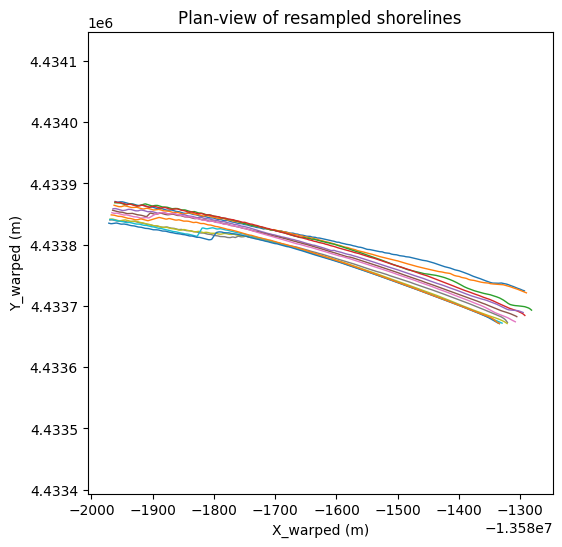

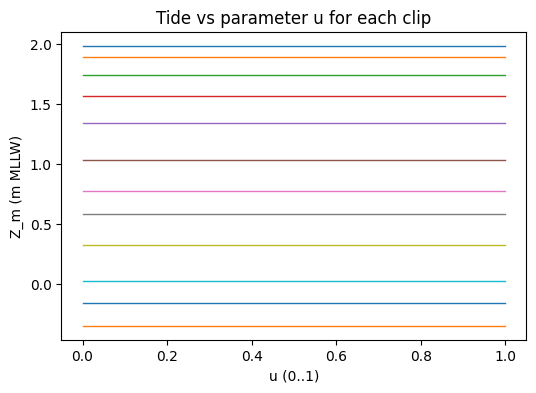

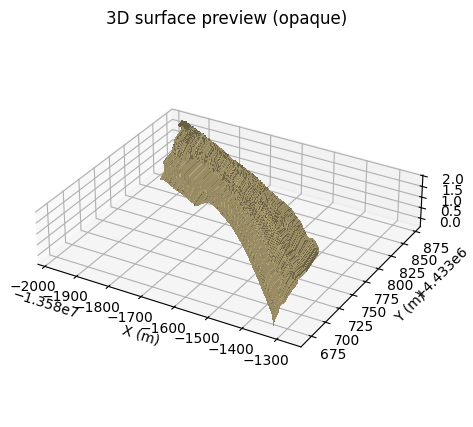

In [ ]:
# 10) Minimal sanity-check plots
try:
    # Plan-view of all resampled shorelines
    plt.figure(figsize=(6,6))
    for e in per_clip_outputs:
        arr = e['df'][['X_warped','Y_warped']].to_numpy(float)
        plt.plot(arr[:,0], arr[:,1], linewidth=1)
    plt.xlabel('X_warped (m)')
    plt.ylabel('Y_warped (m)')
    plt.title('Plan-view of resampled shorelines')
    plt.axis('equal')
    plt.show()

    # u vs Z_m per clip
    plt.figure(figsize=(6,4))
    for e in per_clip_outputs:
        u = e['df']['u'].to_numpy(float)
        z = e['df']['Z_m'].to_numpy(float)
        plt.plot(u, z, linewidth=1)
    plt.xlabel('u (0..1)')
    plt.ylabel('Z_m (m MLLW)')
    plt.title('Tide vs parameter u for each clip')
    plt.show()

    # 3D trisurf preview (decimate faces if too many)
    fig = plt.figure(figsize=(7,5))
    ax = fig.add_subplot(111, projection='3d')
    step = max(1, faces.shape[0] // 15000)
    tri_indices = faces[::step]
    # Solid opaque surface (remove edges & disable AA to reduce pseudo transparency artifacts)
    surf = ax.plot_trisurf(
        V[:,0], V[:,1], V[:,2],
        triangles=tri_indices,
        linewidth=0.0,
        antialiased=False,
        shade=True,
        color='#c2b280',
        edgecolor='none',
        alpha=1.0,
        zorder=2
    )
    # Force facecolors alpha=1 (sometimes matplotlib keeps previous alpha in facecolor array)
    try:
        fc = surf.get_facecolors()
        if fc.shape[1] == 4:
            fc[:,3] = 1.0
            surf.set_facecolors(fc)
    except Exception:
        pass

    xr = float(V[:,0].max() - V[:,0].min())
    yr = float(V[:,1].max() - V[:,1].min()) 
    zr = float(V[:,2].max() - V[:,2].min()) 
    ax.set_box_aspect((xr, yr * 3.5, zr * 60))
    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_zlabel('Z (m MLLW)')
    ax.set_title('3D surface preview (opaque)')
    plt.show()
except Exception as e:
    log("Plotting skipped due to:", e)
